In [1]:
"""
- Initialize population
- Initialize weapon access points
- sample gathering size
"""
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jrand
from abm_event import sample_event, batch_sample
# jax.config.update('jax_platform_name', 'cpu'); print("JAX device:", jax.devices())

In [13]:
propensity_range = [1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
walk_radius_range = [100, 40, 1]
arm_bias_range = [100, 1, 0.01]
arm_weight_range = [10, 1, 0.1]
atrisk_gather_rate_range = [1e-2, 1e-5, 1e-8]
from itertools import product
param_groups = list(product(*[propensity_range, walk_radius_range, arm_bias_range, arm_weight_range, atrisk_gather_rate_range]))
len(param_groups) / 60

6.75

In [3]:
import pickle
from stat_utils import CityParams, EventOutcome, GeneralParams
params = GeneralParams(propensity=1e-9, walk_radius=40, arm_bias=1e-2, arm_weight=1e-1, atrisk_gathering_rate=1e-6)
with open('data/county_data.pkl', 'rb') as f:
    city_data = pickle.load(f)
def hasna(p):
    return any(np.isnan(x) for x in p)
city_data = {k: v for k, v in city_data.items() if not hasna(v['params'])}

FileNotFoundError: [Errno 2] No such file or directory: 'data/county_data.pkl'

In [16]:
from abm_event import conditional_sample
from scipy.special import gammaln
def poisson_ll(n, mu):
    return n*np.log(mu)-mu-gammaln(n+1) #np.log(fact(n))
from stat_utils import grenander_pdf

In [15]:
city_data_f = [c for c in city_data.values() if c['events']]
city_data_base = [c for c in city_data.values() if not c['events']]
city_base_ind = np.arange(len(city_data_base))
np.random.seed(1)
np.random.shuffle(city_base_ind)
subsampled_city_data_base = np.array(city_data_base)[city_base_ind[:400]]
subsampled_city_data = np.concatenate([city_data_f, subsampled_city_data_base])
base_weight = len(city_data_base) / 400
subsample_weights = np.array([1+base_weight*(len(c['events']) == 0) for c in subsampled_city_data])

NameError: name 'city_data' is not defined

In [6]:
def city_ll(city_params, event_list, general_params, timespan, event_distr):
    population, population_density, arm_count, arm_density = city_params
    propensity, walk_radius, arm_bias, arm_weight, atrisk_rate = general_params
    prob_event = 1-event_distr.cdf(5.0)
    pll = poisson_ll(len(event_list), propensity*timespan*population*prob_event)
    eventll = 0
    for event in event_list:
        fatalities = event.fatalities
        eventll += (np.log(event_distr.pdf(fatalities)) - np.log(prob_event))
    return pll + eventll, pll, eventll

# cl = city_ll(c_params, c_events, params, 50, city_distr)

def eval_ds(city_data, general_params, timespan, rng_key):
    ll_data = []
    for c in city_data:
        rng_key, subkey = jrand.split(rng_key, 2)
        c_params = c['params']
        c_events = c['events']
        event_sim = conditional_sample(c_params, general_params, subkey)
        # print(c_params, event_sim.mean(), event_sim.min(), event_sim.max())
        city_distr = grenander_pdf(event_sim+1)
        # print(grenander_pdf)
        ll, pll, eventll = city_ll(c_params, c_events, general_params, timespan, city_distr)
        ll_data.append([ll, pll, eventll])
    return np.array(ll_data)

In [7]:
eval_ds_results = eval_ds(subsampled_city_data, params, 50, jrand.PRNGKey(42))

/home/andrew/abm_violence/stat_utils.py:43: RuntimeWarning: invalid value encountered in scalar multiply
  x_cdf = x_del*knot_slope[xp] + knot_cdf[xp]
/tmp/ipykernel_1104188/1171791529.py:9: RuntimeWarning: divide by zero encountered in log
  eventll += (np.log(event_distr.pdf(fatalities)) - np.log(prob_event))


In [187]:
propensity_range = [1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
walk_radius_range = [100, 40, 1]
arm_bias_range = [100, 1, 0.01]
arm_weight_range = [10, 1, 0.1]
atrisk_gather_rate_range = [1e-2, 1e-5, 1e-8]
from itertools import product
param_groups = list(product(*[propensity_range, walk_radius_range, arm_bias_range, arm_weight_range, atrisk_gather_rate_range]))
rng_key = jrand.PRNGKey(42)
eval_dict = {}
for i, group in enumerate(param_groups):
    rng_key, subkey = jrand.split(rng_key, 2)
    params = GeneralParams(*group)
    eval_ds_results = eval_ds(subsampled_city_data, params, 50, subkey)
    eval_dict[params] = eval_ds_results
    if(i % 10 == 0):
        with open('data/ll_eval.pkl', 'wb') as f:
            pickle.dump(eval_dict, f)


KeyboardInterrupt: 

GeneralParams(propensity=1e-10, walk_radius=100, arm_bias=100, arm_weight=10, atrisk_gathering_rate=0.01) (1e-10, 100, 100, 10, 0.01)


In [171]:
print(len(list(param_groups))/60)

25.0


In [157]:
total_ll = np.sum(eval_ds_results*subsample_weights.reshape((-1, 1)), axis=0)
print(total_ll)

[-1142.76273617  -771.66826835  -371.09446782]


In [150]:
print(eval_ds_results)
print(subsampled_city_data)

[[-7.30957473e+00 -4.47045893e+00 -2.83911580e+00]
 [-4.44566402e+00 -1.74086758e+00 -2.70479644e+00]
 [-3.57355794e+00 -1.22962772e+00 -2.34393022e+00]
 ...
 [-5.85988468e-04 -5.85988468e-04  0.00000000e+00]
 [-9.03690457e-06 -9.03690457e-06  0.00000000e+00]
 [-1.02131180e-03 -1.02131180e-03  0.00000000e+00]]
[{'events': [EventOutcome(date='8/5/2012', fatalities=7, injured=3, total_victims=10)], 'params': CityParams(population=36473, population_density=495.0, arm_count=1.0, arm_density=0.013571683162887616)}
 {'events': [EventOutcome(date='5/23/2014', fatalities=6, injured=13, total_victims=19)], 'params': CityParams(population=194950, population_density=1743.9, arm_count=5.0, arm_density=0.04472685303924084)}
 {'events': [EventOutcome(date='2/26/20', fatalities=5, injured=0, total_victims=5)], 'params': CityParams(population=1290221, population_density=2287.4, arm_count=10.0, arm_density=0.017728745695504877)}
 {'events': [EventOutcome(date='5/14/22', fatalities=10, injured=3, total_

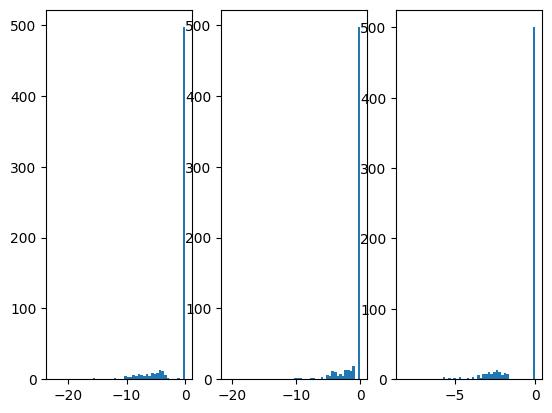

In [148]:
fig, axes = plt.subplots(1, 3)
axes[0].hist(eval_ds_results[:, 0], bins=50)
axes[1].hist(eval_ds_results[:, 1], bins=50)
axes[2].hist(eval_ds_results[:, 2], bins=50)
plt.show()

In [133]:
print(eval_ds_results)

[[nan nan nan]
 [nan nan nan]
 [nan nan nan]
 ...
 [nan nan  0.]
 [nan nan  0.]
 [nan nan  0.]]


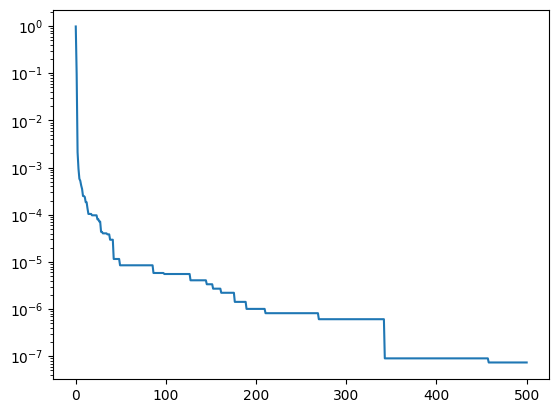

In [92]:
# rng_key = jrand.PRNGKey(125)
# city_samples = conditional_sample(c_params, params, rng_key)
# city_distr = grenander_pdf(city_samples+1)
x = np.linspace(0, 500, 500)
plt.plot(x, city_distr.pdf(x))
plt.yscale('log')
plt.show()

-4.4935030283021655 -7.949574176153804


In [ ]:
from scipy.stats import poisson


In [ ]:
city_pdf = grenander_pdf(city_samples+1)

array([0.72952293, 0.9838116 , 0.99505744, 0.99997247])

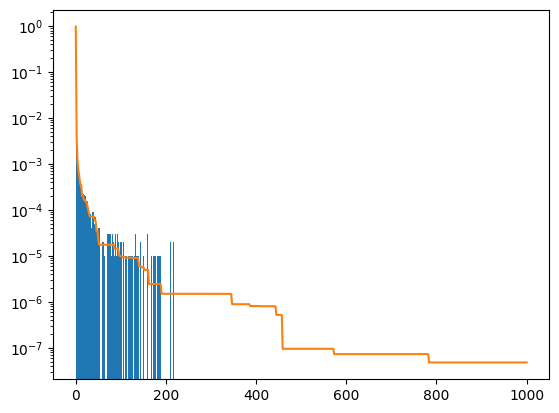

In [65]:
city_pdf.cdf(np.array([0.7, 1.99, 20, 900]))

plt.hist(np.array(city_samples), bins=np.linspace(0, 250, 250), density=True)
plt.yscale('log')
x = np.linspace(0, 1000, 500)
plt.plot(x, city_pdf.pdf(x))
plt.show()

In [2]:
rng_key = jrand.PRNGKey(125)
s = int(1e5)
rng_batch = jrand.split(rng_key, s)
event_samples = batch_sample(jnp.full(s, 20), jnp.full(s, 12000), jnp.full(s, 0.8), rng_batch)

In [6]:
s = int(1e5)
for i in range(10):
    rng_batch = jrand.split(rng_key, s)
    event_samples = batch_sample(jnp.full(s, 20), jnp.full(s, 12000), jnp.full(s, 0.8), rng_batch)

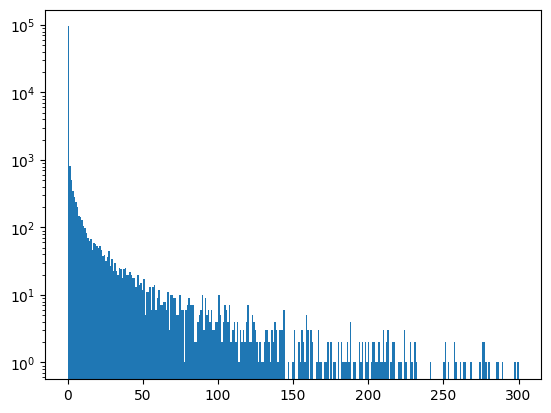

In [4]:
plt.hist(event_samples, bins=np.linspace(0, 300, 300))
plt.yscale('log')
plt.show()

In [ ]:
rng = np.random.default_rng(seed=None)
population_density = 12000
weapon_density = 8000

"""
Params: 
    access_coef
    walk_radius
    atrisk_gathering_rate
    weibull_scale
    weibull_shape
"""
from stat_utils import sample_event, GeneralParams, CityParams

def sample_n(n, rng, params: GeneralParams, city_params: CityParams):
    population_grid = np.zeros((50, 50))
    access_grid = np.zeros_like(population_grid)
    walk_grid = np.zeros_like(population_grid)
    sims = []
    for i in range(n):
        sims.append(sample_event(params.walk_radius, city_params.population_density, city_params.arm_density, 
                                population_grid, access_grid, walk_grid, rng))
    sims = np.array(sims)
    sims.sort()
    return sims

In [32]:
cities = list(city_data.values())
print(cities[:150])

[{'events': [], 'params': CityParams(population=330, population_density=174.8, arm_count=0.0, arm_density=0.0)}, {'events': [], 'params': CityParams(population=49904, population_density=1567.0, arm_count=7.0, arm_density=0.21980201987816608)}, {'events': [], 'params': CityParams(population=2439, population_density=1460.2, arm_count=3.0, arm_density=1.7960639606396065)}, {'events': [], 'params': CityParams(population=415, population_density=43.2, arm_count=1.0, arm_density=0.10409638554216868)}, {'events': [], 'params': CityParams(population=638, population_density=403.6, arm_count=0.0, arm_density=0.0)}, {'events': [], 'params': CityParams(population=695, population_density=168.4, arm_count=1.0, arm_density=0.24230215827338134)}, {'events': [], 'params': CityParams(population=200, population_density=139.4, arm_count=1.0, arm_density=0.6970000000000001)}, {'events': [], 'params': CityParams(population=319, population_density=442.9, arm_count=0.0, arm_density=0.0)}, {'events': [], 'param

In [ ]:
event_counts = sample_n(int(1e4), rng, params, cities[2]['params'])

In [41]:
from stat_utils import GrenanderDistr, grenander_pdf
gd = grenander_pdf(event_counts+1)

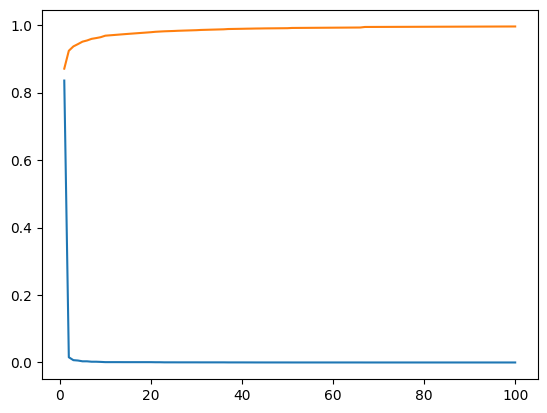

In [42]:
x = np.linspace(1, 100, 100)
plt.plot(x, gd.pdf(x))
plt.plot(x, gd.cdf(x))
plt.show()

In [ ]:
from stat_utils import grenander_pdf_eval, grenander_cdf_eval
from stat_utils import GrenanderDistr
from scipy.special import gammaln
def city_ll(city_events, f_data, params, city_params, date_range=50):
    N_event = len(city_events)
    mu = params.propensity*city_params.population*date_range
    p_event = f_data.cdf(4.0)
    mu_corr = mu *p_event
    poisson_ll = 


{'events': [],
 'params': CityParams(population=330, density=174.8, arm_count=0.0, arm_density=0.0)}

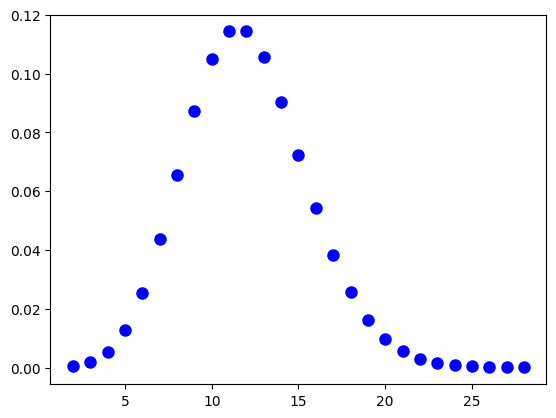

In [ ]:
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)
mu = 12
x = np.arange(poisson.ppf(0.0001, mu),
              poisson.ppf(0.99999, mu))
ax.plot(x, , 'bo', ms=8, label='poisson pmf')

In [6]:
res = ecdf(event_counts+1)
print(res.cdf.quantiles, res.cdf.probabilities)
propensity = 1e-7 #Event / year / person


NameError: name 'ecdf' is not defined

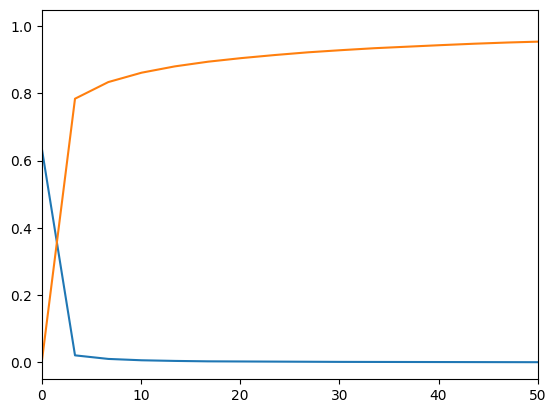

In [33]:
from stat_utils import *
knot_x, knot_slope = grenander_pdf(event_counts+1)
x = np.linspace(0, 500, 150)
x_pdf = grenander_pdf_eval(x, knot_x, knot_slope)
x_cdf = grenander_cdf_eval(x, knot_x, knot_slope)
plt.plot(x, x_pdf)
plt.plot(x, x_cdf)
plt.xlim(0, 50)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (259,) and (260,)

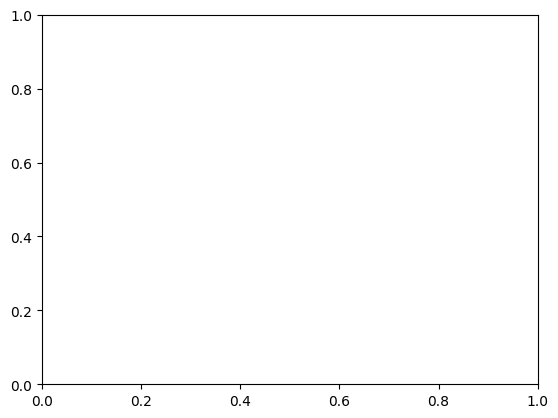

In [21]:
plt.plot(knot_ind, knot_slope)
plt.xlim(0, 500)
plt.ylim(0, 500)
plt.show()

In [ ]:
res = ecdf(event_counts)
plt.plot(res.cdf.quantiles, res.cdf.probabilities)

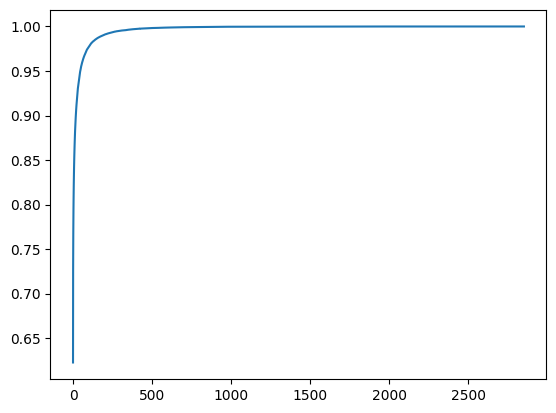

In [7]:
from scipy.stats import ecdf
res = ecdf(event_counts)
plt.plot(res.cdf.quantiles, res.cdf.probabilities)

(0.0, 1.0)

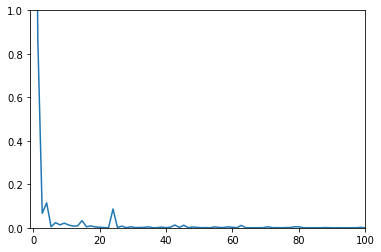

In [11]:
x = np.linspace(0.001, 2000, 1500)
pdf_est = grenander_pdf(x, event_counts)
plt.plot(x, pdf_est)
plt.xlim(-1, 100)
plt.ylim(0, 1)

In [ ]:
p

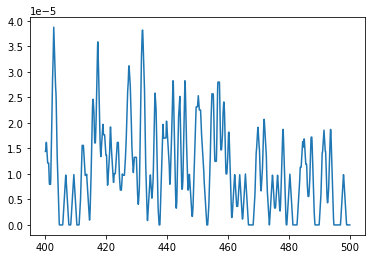

1.0 1.0


In [ ]:
def kernel_density(x, alpha=1):
    return np.maximum(1-np.abs(x*alpha), 0)*alpha
def kernel_cdf(x, alpha=1):
    x = x*alpha
    return ((x > -1) & (x < 0))*0.5*(x+1)*(x+1) + ((x >= 0) & (x < 1))*(1-0.5*(1-x)*(1-x)) + (x >= 1)
def kernel_pdf_estimate(x, data, kernel_density):
    return np.mean(kernel_density(x.reshape((1, -1))-data.reshape((-1, 1))), axis=0)
def kernel_cdf_estimate(x, data, kernel_cdf):
    return np.mean(kernel_cdf(x.reshape((1, -1))-data.reshape((-1, 1))), axis=0)

x = np.linspace(400, 500, 1500)
# plt.plot(x, kernel_density(x-12, alpha=0.1)); plt.plot(x, kernel_cdf(x-12, alpha=0.1))
plt.plot(x, kernel_pdf_estimate(x, event_counts, lambda x: kernel_density(x, alpha=1)))
# plt.plot(x, kernel_cdf_estimate(x, event_counts, lambda x: kernel_cdf(x, alpha=1)))
plt.show()

In [8]:
from sklearn.neighbors import KernelDensity
import numpy as np

counts = np.sort(np.array(event_counts))
counts

array([   0.        ,    0.        ,    0.        , ...,  766.24928879,
       1017.44752956, 1454.57192253])

In [7]:
event_counts = [sample_event(population_density, weapon_density, population_grid, access_grid, walk_grid, rng) for _ in range(int(1e4))]
d = {}
for pop_dens in np.linspace(0, 30000, 500):
    event_counts = [sample_event(population_density, weapon_density, population_grid, access_grid, walk_grid, rng) for _ in range(int(1e4))]
    d[pop_dens] = event_counts

In [4]:
propensity = 1e-6 #Dangerous person / person / year
dataset = None #county: [(time, fatalities)]

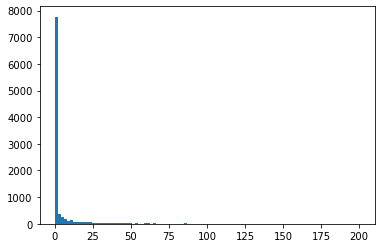

In [5]:
plt.hist(event_counts, bins=np.linspace(0, 200, 100))
plt.show()

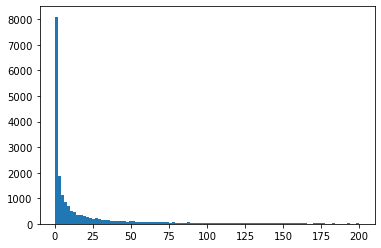

In [15]:
loc_gathering_size = 10*rng.weibull(0.4, (20000,))
plt.hist(loc_gathering_size, bins=np.linspace(0, 200, 100))
plt.show()

In [ ]:
def init_background_density(board, n, rng):
    board = np.copy(board)
    return board